## Importanto o dataset

In [ ]:
import seaborn as sns
import requests, zipfile, io
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
url = "https://github.com/roneysco/Fake.br-Corpus/archive/refs/heads/master.zip"
r = requests.get(url)
z = zipfile.ZipFile(io.BytesIO(r.content))
z.extractall(".")  # cria a pasta Fake.br-Corpus-master/

In [ ]:
os.listdir(".")

['.config', 'Fake.br-Corpus-master', 'sample_data']

Mostra a quantidade de arquivos em cada diretório `full_texts`

In [ ]:
print(len(os.listdir("Fake.br-Corpus-master/full_texts/fake-meta-information")))
print(len(os.listdir("Fake.br-Corpus-master/full_texts/true-meta-information")))

3600
3600


# organizando colunas

In [ ]:
import pandas as pd
import glob, os

def carregar_textos(pasta, label):
    registros = []
    for caminho in sorted(glob.glob(os.path.join(pasta, "*.txt"))):
        repWith = ""
        if (label == 0):
            repWith = "t"
        id_noticia = os.path.basename(caminho).replace(".txt", repWith)
        with open(caminho, encoding="utf-8") as f:
            texto = f.read()
        registros.append({"id": id_noticia, "texto": texto, "label": label})
    return pd.DataFrame(registros)

df_fake = carregar_textos("Fake.br-Corpus-master/full_texts/fake", label=1)
df_true = carregar_textos("Fake.br-Corpus-master/full_texts/true", label=0)
df_textos = pd.concat([df_fake, df_true], ignore_index=True)

colunas_meta = [
    "autor",
    "link",
    "categoria",
    "data_publicacao",
    "num_tokens",
    "num_palavras",
    "num_types", "num_links", "num_maiusculas",
    "num_verbos", "num_verbos_subj_imp", "num_substantivos", "num_adjetivos",
    "num_adverbios", "num_verbos_modais", "num_pron_1_2_sing", "num_pron_1_plural",
    "num_pronomes", "pausalidade", "num_caracteres", "tam_medio_sentenca",
    "tam_medio_palavra", "pct_erros_ortograficos", "emotividade", "diversidade"
]


def carregar_metadados(pasta, label):
    registros = []
    for caminho in sorted(glob.glob(os.path.join(pasta, "*.txt"))):
        repWith = ""
        if (label == 0):
          repWith = "t"
        id_noticia = os.path.basename(caminho).replace("-meta.txt", repWith)
        with open(caminho, encoding="utf-8") as f:
            valores = [l.strip() for l in f.readlines()]
        registro = dict(zip(colunas_meta, valores))
        registro["id"], registro["label"] = id_noticia, label
        registros.append(registro)
    return pd.DataFrame(registros)

df_meta = pd.concat([
    carregar_metadados("Fake.br-Corpus-master/full_texts/fake-meta-information", 1),
    carregar_metadados("Fake.br-Corpus-master/full_texts/true-meta-information", 0),
], ignore_index=True)

df = df_textos.merge(df_meta.drop(columns="label"), on="id")

# metadados vêm como string do .txt — precisa converter
colunas_numericas = colunas_meta[4:]  # a partir de num_tokens
df[colunas_numericas] = df[colunas_numericas].apply(pd.to_numeric, errors="coerce")

In [ ]:
print(df_meta.shape)
print(df_meta.columns.tolist())

(7200, 27)
['autor', 'link', 'categoria', 'data_publicacao', 'num_tokens', 'num_palavras', 'num_types', 'num_links', 'num_maiusculas', 'num_verbos', 'num_verbos_subj_imp', 'num_substantivos', 'num_adjetivos', 'num_adverbios', 'num_verbos_modais', 'num_pron_1_2_sing', 'num_pron_1_plural', 'num_pronomes', 'pausalidade', 'num_caracteres', 'tam_medio_sentenca', 'tam_medio_palavra', 'pct_erros_ortograficos', 'emotividade', 'diversidade', 'id', 'label']


In [ ]:
print(df_textos["id"].head())
print(df_meta["id"].head())

0       1
1      10
2     100
3    1000
4    1001
Name: id, dtype: object
0       1
1      10
2     100
3    1000
4    1001
Name: id, dtype: object


In [ ]:
df.head()

,id,texto,label,autor,link,categoria,data_publicacao,num_tokens,num_palavras,num_types,...,num_pron_1_2_sing,num_pron_1_plural,num_pronomes,pausalidade,num_caracteres,tam_medio_sentenca,tam_medio_palavra,pct_erros_ortograficos,emotividade,diversidade
0,1,Kátia Abreu diz que vai colocar sua expulsão e...,1,mrk,https://ceticismopolitico.com/2017/11/30/katia...,politica,2017-11-30,211,185,120,...,2,0,26,2.000000,815,14.23080,4.40541,0.000000,0.263158,0.648649
1,10,"Dr. Ray peita Bolsonaro, chama-o de conservad...",1,None,https://ceticismopolitico.com/2017/11/24/dr-ra...,politica,2017-11-24,289,254,163,...,1,0,20,2.500000,1205,18.14290,4.74409,0.007874,0.241667,0.641732
2,100,Reinaldo Azevedo desmascarado pela Polícia Fed...,1,None,https://afolhabrasil.com.br/politica/reinaldo-...,politica,2017-05-23,304,275,170,...,0,0,18,1.812500,1344,17.18750,4.88727,0.003636,0.127820,0.618182
3,1000,Relatório assustador do BNDES mostra dinheiro ...,1,None,https://www.diariodobrasil.org/relatorio-assus...,politica,24/07/2017,639,572,316,...,0,0,34,2.680000,3122,22.88000,5.45804,0.001748,0.229008,0.552448
4,1001,"Radialista americano fala sobre o PT: ""Eles ve...",1,None,https://www.diariodobrasil.org/radialista-amer...,politica,25/07/2017,128,111,82,...,1,0,12,0.894737,515,5.84211,4.63964,0.000000,0.269231,0.738739


In [ ]:
original_df = df.copy()
original_df.head()
#result_df = result_df[['texto','num_maiusculas']]
#result_df.head()

,id,texto,label,autor,link,categoria,data_publicacao,num_tokens,num_palavras,num_types,...,num_pron_1_2_sing,num_pron_1_plural,num_pronomes,pausalidade,num_caracteres,tam_medio_sentenca,tam_medio_palavra,pct_erros_ortograficos,emotividade,diversidade
0,1,Kátia Abreu diz que vai colocar sua expulsão e...,1,mrk,https://ceticismopolitico.com/2017/11/30/katia...,politica,2017-11-30,211,185,120,...,2,0,26,2.000000,815,14.23080,4.40541,0.000000,0.263158,0.648649
1,10,"Dr. Ray peita Bolsonaro, chama-o de conservad...",1,None,https://ceticismopolitico.com/2017/11/24/dr-ra...,politica,2017-11-24,289,254,163,...,1,0,20,2.500000,1205,18.14290,4.74409,0.007874,0.241667,0.641732
2,100,Reinaldo Azevedo desmascarado pela Polícia Fed...,1,None,https://afolhabrasil.com.br/politica/reinaldo-...,politica,2017-05-23,304,275,170,...,0,0,18,1.812500,1344,17.18750,4.88727,0.003636,0.127820,0.618182
3,1000,Relatório assustador do BNDES mostra dinheiro ...,1,None,https://www.diariodobrasil.org/relatorio-assus...,politica,24/07/2017,639,572,316,...,0,0,34,2.680000,3122,22.88000,5.45804,0.001748,0.229008,0.552448
4,1001,"Radialista americano fala sobre o PT: ""Eles ve...",1,None,https://www.diariodobrasil.org/radialista-amer...,politica,25/07/2017,128,111,82,...,1,0,12,0.894737,515,5.84211,4.63964,0.000000,0.269231,0.738739


In [ ]:
colunas_uteis = [
    'id',
    'texto',
    'tem_autor',
    # "autor", # Deixar como binário (tem ou não autor)
    # "link", # Talvez te um outro jeito de avaliar
    # "categoria",
    # "data_publicacao",
    # "num_tokens",
    # "num_palavras",
    # "num_types",
    "num_links",
    "num_maiusculas",
    "num_verbos",
    "num_verbos_subj_imp",
    "num_substantivos",
    "num_adjetivos",
    "num_adverbios",
    "num_verbos_modais",
    "num_pron_1_2_sing",
    "num_pron_1_plural",
    "num_pronomes",
    "pausalidade",
    # "num_caracteres",
    "tam_medio_sentenca",
    "tam_medio_palavra",
    "pct_erros_ortograficos",
    "emotividade",
    "diversidade",
    "label"
]
df["tem_autor"] = (
    df["autor"].fillna("").astype(str).str.strip().isin(["", "None", "none", "NULL"]).eq(False)
).astype(int)
df["num_links"] = df["num_links"].fillna(0.0)
uteis_df = df[colunas_uteis].copy()

uteis_df.sample(1)

,id,texto,tem_autor,num_links,num_maiusculas,num_verbos,num_verbos_subj_imp,num_substantivos,num_adjetivos,num_adverbios,...,num_pron_1_2_sing,num_pron_1_plural,num_pronomes,pausalidade,tam_medio_sentenca,tam_medio_palavra,pct_erros_ortograficos,emotividade,diversidade,label
6544,407t,"Traficante, primeira-dama e ex-guarda-costas e...",1,0.0,35,434,13,699,140,173,...,10,0,213,3.17213,21.9508,4.5829,0.000747,0.276258,0.357356,0


In [ ]:
uteis_df.tail()

,id,texto,tem_autor,num_links,num_maiusculas,num_verbos,num_verbos_subj_imp,num_substantivos,num_adjetivos,num_adverbios,...,num_pron_1_2_sing,num_pron_1_plural,num_pronomes,pausalidade,tam_medio_sentenca,tam_medio_palavra,pct_erros_ortograficos,emotividade,diversidade,label
7195,995t,"Para jornal britânico, ação contra Lula na Lav...",1,0.0,7,71,1,184,24,12,...,0,0,27,3.50000,28.3500,4.77601,0.001764,0.141176,0.513228,0
7196,996t,Temer diz que acionou PF e Cade para investiga...,1,0.0,8,158,5,253,40,54,...,7,2,43,3.01818,17.2545,4.76291,0.002107,0.228710,0.420443,0
7197,997t,Os obstáculos políticos de Temer em 2017. Espe...,1,0.0,23,220,17,398,82,70,...,0,0,65,3.50746,21.8358,4.88175,0.000000,0.245955,0.414901,0
7198,998t,"Sexta-feira, 15 de setembro de 2017. Boa noite...",1,0.0,9,103,3,190,29,25,...,1,2,31,2.76471,19.0588,4.63426,0.001543,0.184300,0.614198,0
7199,999t,"'Não me envolvo em política', diz brasileiro q...",1,0.0,35,366,17,451,88,155,...,36,4,234,3.24324,27.1081,4.56979,0.004985,0.297430,0.373380,0


In [ ]:
num_pal = df["num_palavras"]

In [ ]:
df = uteis_df

In [ ]:
df[df['label']==0]['tam_medio_sentenca'].mean(),df[df['label']==0]['tam_medio_sentenca'].std()

(np.float64(21.150988977777775), 5.241315249585977)

In [ ]:
df.iloc[:,2]

,tem_autor
0,1
1,0
2,0
3,0
4,0
...,...
7195,1
7196,1
7197,1
7198,1


# truncar texto

In [ ]:
def truncar(texto, n=200):
    return " ".join(str(texto).split()[:n])

df["texto_trunc"] = df["texto"].apply(truncar)

In [ ]:
df.loc[df["id"] == "3000t"]["texto"].str.len()

,texto
5824,2793


In [ ]:
df.loc[df["id"] == "3000t"]["texto_trunc"].str.len()

,texto_trunc
5824,1277


In [ ]:
df_meta

,autor,link,categoria,data_publicacao,num_tokens,num_palavras,num_types,num_links,num_maiusculas,num_verbos,...,num_pronomes,pausalidade,num_caracteres,tam_medio_sentenca,tam_medio_palavra,pct_erros_ortograficos,emotividade,diversidade,id,label
0,mrk,https://ceticismopolitico.com/2017/11/30/katia...,politica,2017-11-30,211,185,120,0,6,30,...,26,2.0,815,14.2308,4.40541,0.0,0.263158,0.648649,1,1
1,None,https://ceticismopolitico.com/2017/11/24/dr-ra...,politica,2017-11-24,289,254,163,0,0,56,...,20,2.5,1205,18.1429,4.74409,0.00787402,0.241667,0.641732,10,1
2,None,https://afolhabrasil.com.br/politica/reinaldo-...,politica,2017-05-23,304,275,170,0,0,45,...,18,1.8125,1344,17.1875,4.88727,0.00363636,0.12782,0.618182,100,1
3,None,https://www.diariodobrasil.org/relatorio-assus...,politica,24/07/2017,639,572,316,1,14,87,...,34,2.68,3122,22.88,5.45804,0.00174825,0.229008,0.552448,1000,1
4,None,https://www.diariodobrasil.org/radialista-amer...,politica,25/07/2017,128,111,82,0,1,21,...,12,0.894737,515,5.84211,4.63964,0.0,0.269231,0.738739,1001,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7195,"Célia Froufe, correspondente, O Estado de S.Paulo","http://politica.estadao.com.br/noticias/geral,...",politica,22 de novembro de 2016,637,567,291,0,7,71,...,27,3.5,2708,28.35,4.77601,0.00176367,0.141176,0.513228,995t,0
7196,"Por G1, Brasília",https://g1.globo.com/politica/noticia/temer-di...,politica,09/02/2018 08h25,1115,949,399,0,8,158,...,43,3.01818,4520,17.2545,4.76291,0.00210748,0.22871,0.420443,996t,0
7197,"Por Luciana Amaral, G1, Brasília",https://g1.globo.com/politica/noticia/os-obsta...,politica,31/12/2016 05h00,1698,1463,607,0,23,220,...,65,3.50746,7142,21.8358,4.88175,0.0,0.245955,0.414901,997t,0
7198,Por G1,https://g1.globo.com/resumo-do-dia/noticia/sex...,sociedade_cotidiano,15/09/2017 20h46,742,648,398,None,9,103,...,31,2.76471,3003,19.0588,4.63426,0.00154321,0.1843,0.614198,998t,0


# Verificando coluna a coluna

Esta coluna não é útil pois 87% dos valores são 0 ou None

In [ ]:
import matplotlib.pyplot as plt

## Num links

In [ ]:
100*df_meta['num_links'].value_counts()/len(df_meta['num_links'])

,count
num_links,
0,68.138889
None,19.347222
1,9.263889
2,2.305556
3,0.625000
4,0.208333
5,0.041667
6,0.027778
11,0.013889


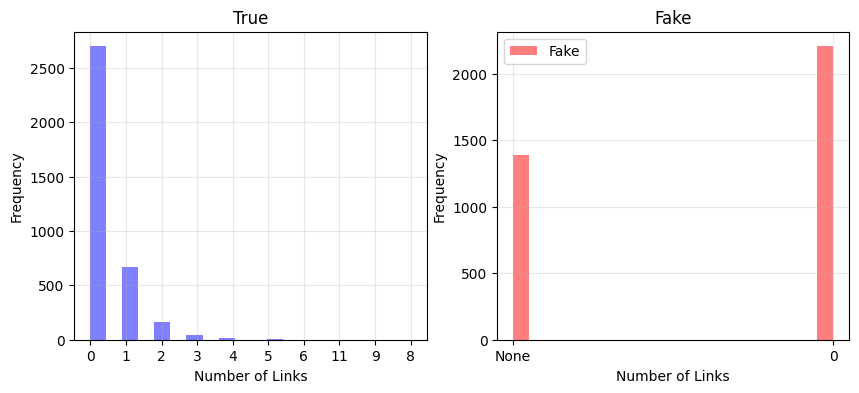

In [ ]:
fig, ax = plt.subplots(1,2,figsize=(10, 4))

ax[0].hist(df_meta[df_meta['label'] == 1]['num_links'], bins=20, alpha=0.5, label='True', color='blue')
ax[1].hist(df_meta[df_meta['label'] == 0]['num_links'], bins=20, alpha=0.5, label='Fake', color='red')
ax[0].set_title('True')
ax[1].set_title('Fake')
ax[0].set_xlabel('Number of Links')
ax[1].set_xlabel('Number of Links')
ax[0].set_ylabel('Frequency')
ax[1].set_ylabel('Frequency')
ax[0].grid(alpha=0.3)
ax[1].grid(alpha=0.3)
plt.legend()

plt.show()

## autor

In [ ]:
100*df_meta['autor'].value_counts()/len(df_meta['autor'])

,count
autor,
None,49.652778
Por G1,4.597222
Por BBC,3.263889
José Nêumanne,2.402778
"Por G1, Brasília",1.194444
...,...
"Por Luiza Tenente e Vanessa Fajardo, G1",0.013889
"Por Hosana Morais, G1 RO",0.013889
Zander Navarro,0.013889


### não vai usar

In [ ]:
df_meta[df_meta['label'] == 1]['categoria'].value_counts()

,count
categoria,
politica,2090
tv_celebridades,772
sociedade_cotidiano,638
ciencia_tecnologia,56
economia,22
religiao,22


# Analisar

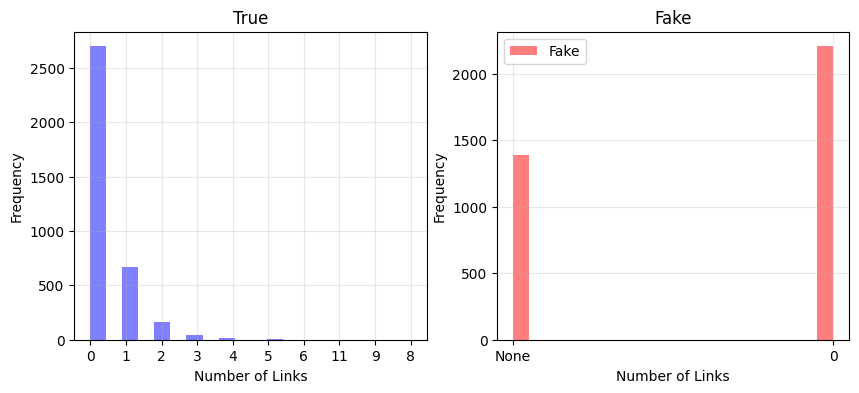

In [ ]:
fig, ax = plt.subplots(1,2,figsize=(10, 4))

ax[0].hist(df_meta[df_meta['label'] == 1]['num_links'], bins=20, alpha=0.5, label='True', color='blue')
ax[1].hist(df_meta[df_meta['label'] == 0]['num_links'], bins=20, alpha=0.5, label='Fake', color='red')
ax[0].set_title('True')
ax[1].set_title('Fake')
ax[0].set_xlabel('Number of Links')
ax[1].set_xlabel('Number of Links')
ax[0].set_ylabel('Frequency')
ax[1].set_ylabel('Frequency')
ax[0].grid(alpha=0.3)
ax[1].grid(alpha=0.3)
plt.legend()

plt.show()

## Convertendo string para integer

In [ ]:
df_meta['num_maiusculas'] = df_meta['num_maiusculas'].astype(int)
df_meta['num_maiusculas'].unique()

array([  6,   0,  14,   1,   5,   3,   7,   2,   9,   4,   8,  18,  11,
        25,  12,  29,  30,  10,  22,  23,  21,  17,  15,  19,  16,  13,
        26,  24,  68,  88,  28,  20,  36,  31,  71,  33,  47,  32,  27,
       132,  37,  45,  52,  39,  34,  38,  53,  57,  69,  42,  60,  48,
        43,  35, 233, 121,  49,  54,  46, 107,  70,  41,  65,  40,  91,
        59,  62,  50,  44,  51,  73, 148,  58, 106, 157,  81, 122])

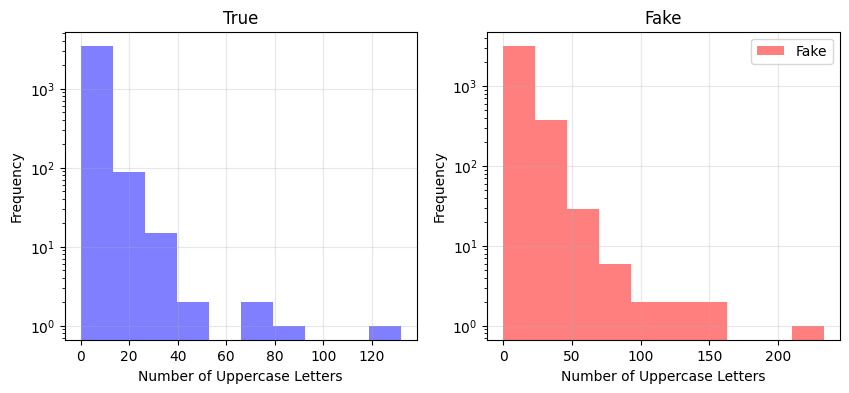

In [ ]:
fig, ax = plt.subplots(1,2,figsize=(10, 4))

ax[0].hist(df_meta[df_meta['label'] == 1]['num_maiusculas'], bins=10, alpha=0.5, label='True', color='blue')
ax[1].hist(df_meta[df_meta['label'] == 0]['num_maiusculas'], bins=10, alpha=0.5, label='Fake', color='red')
ax[0].set_title('True')
ax[1].set_title('Fake')
ax[0].set_xlabel('Number of Uppercase Letters')
ax[1].set_xlabel('Number of Uppercase Letters')
ax[0].set_ylabel('Frequency')
ax[1].set_ylabel('Frequency')
ax[0].grid(alpha=0.3)
ax[1].grid(alpha=0.3)
ax[0].set_yscale('log')
ax[1].set_yscale('log')
plt.legend()

plt.show()


### avaliar depois de truncar o texto


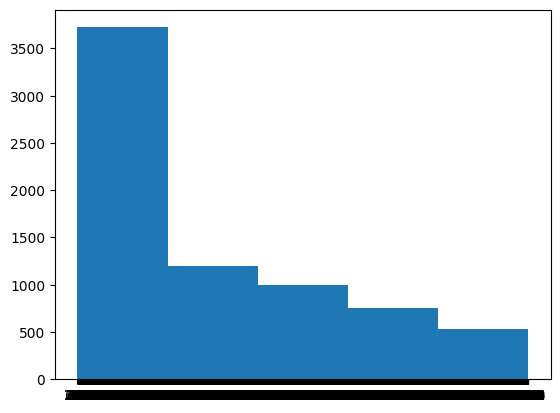

In [ ]:
plt.hist(df_meta['num_tokens'], bins=5);

In [ ]:
df_meta[df_meta['label'] == 1]['num_tokens'].value_counts()

,count
num_tokens,
135,34
187,28
109,27
190,25
148,25
...,...
596,1
362,1
549,1


In [ ]:
df_meta[df_meta['label'] == 0]['num_tokens'].value_counts()

,count
num_tokens,
578,9
966,8
677,8
681,8
842,8
...,...
1119,1
4995,1
4797,1


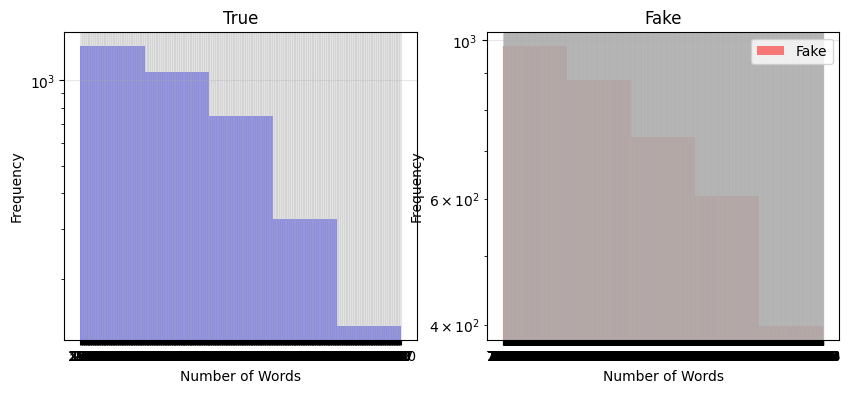

In [ ]:

fig, ax = plt.subplots(1,2,figsize=(10, 4))

ax[0].hist(df_meta[df_meta['label'] == 1]['num_palavras'], bins=5, alpha=0.5, label='True', color='blue')
ax[1].hist(df_meta[df_meta['label'] == 0]['num_palavras'], bins=5, alpha=0.5, label='Fake', color='red')
ax[0].set_title('True')
ax[1].set_title('Fake')
ax[0].set_xlabel('Number of Words')
ax[1].set_xlabel('Number of Words')
ax[0].set_ylabel('Frequency')
ax[1].set_ylabel('Frequency')
ax[0].grid(alpha=0.3)
ax[1].grid(alpha=0.3)
ax[0].set_yscale('log')
ax[1].set_yscale('log')
plt.legend()

plt.show()

In [ ]:
df_meta[df_meta['label'] == 0]['num_types'].value_counts()

,count
num_types,
342,19
433,15
423,15
362,15
386,14
...,...
863,1
1007,1
1137,1


Numero de Substantivos

(array([4115., 1198.,  963.,  682.,  242.]),
 array([  0. , 150.8, 301.6, 452.4, 603.2, 754. ]),
 <BarContainer object of 5 artists>)

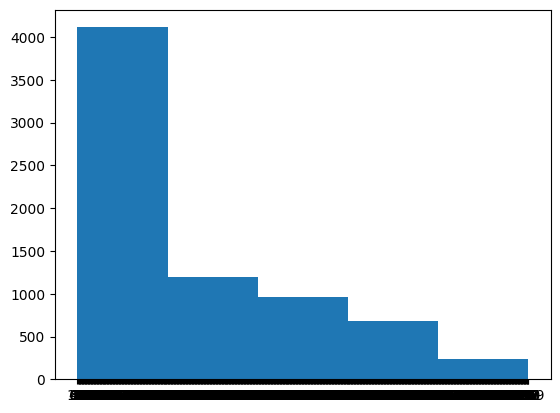

In [ ]:
plt.hist(df_meta["num_substantivos"], bins=5)

In [ ]:
df['taxa_substantivos'] = df["num_substantivos"] / num_pal

(array([2.400e+01, 3.390e+02, 2.132e+03, 3.628e+03, 9.390e+02, 1.060e+02,
        2.500e+01, 1.000e+00, 2.000e+00, 4.000e+00]),
 array([0.15389   , 0.19546555, 0.2370411 , 0.27861666, 0.32019221,
        0.36176776, 0.40334332, 0.44491887, 0.48649442, 0.52806998,
        0.56964553]),
 <BarContainer object of 10 artists>)

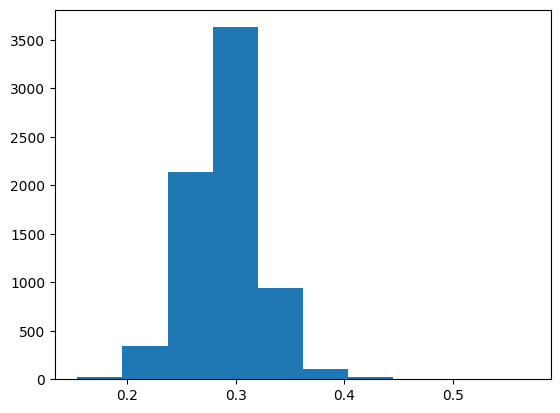

In [ ]:
plt.hist(df["taxa_substantivos"])

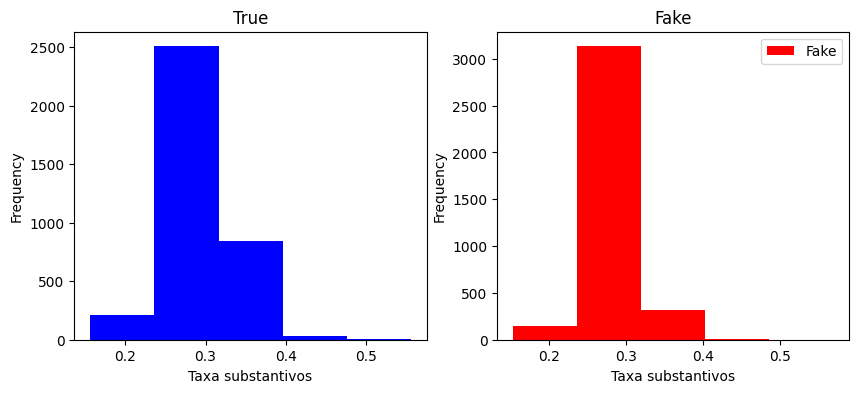

In [ ]:
fig, ax = plt.subplots(1,2,figsize=(10, 4))

ax[0].hist(df[df['label'] == 1]['taxa_substantivos'], bins=5, label='True', color='blue')
ax[1].hist(df[df['label'] == 0]['taxa_substantivos'], bins=5, label='Fake', color='red')
ax[0].set_title('True')
ax[1].set_title('Fake')
ax[0].set_xlabel('Taxa substantivos')
ax[1].set_xlabel('Taxa substantivos')
ax[0].set_ylabel('Frequency')
ax[1].set_ylabel('Frequency')
plt.legend()

plt.show()

A taxa de substantivos em notícias verdadeiras é menor do que em notícias falsas na maioria das vezes

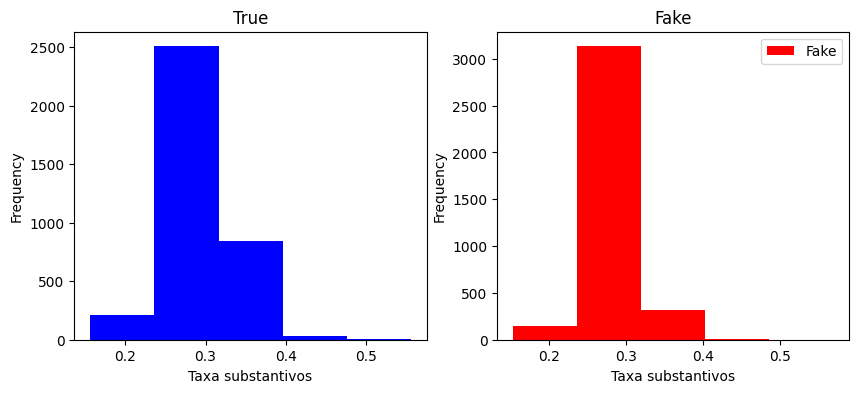

In [ ]:
fig, ax = plt.subplots(1,2,figsize=(10, 4))

ax[0].hist(df[df['label'] == 1]['taxa_substantivos'], bins=5, label='True', color='blue')
ax[1].hist(df[df['label'] == 0]['taxa_substantivos'], bins=5, label='Fake', color='red')
ax[0].set_title('True')
ax[1].set_title('Fake')
ax[0].set_xlabel('Taxa substantivos')
ax[1].set_xlabel('Taxa substantivos')
ax[0].set_ylabel('Frequency')
ax[1].set_ylabel('Frequency')
plt.legend()

plt.show()

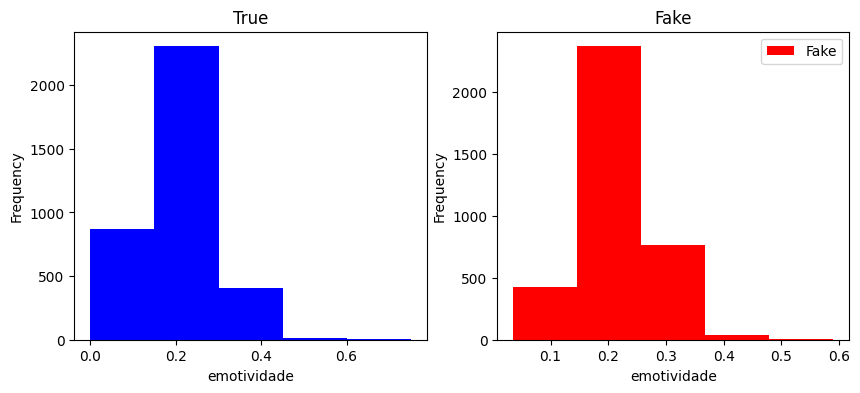

In [ ]:
fig, ax = plt.subplots(1,2,figsize=(10, 4))

ax[0].hist(df[df['label'] == 1]['emotividade'], bins=5, label='True', color='blue')
ax[1].hist(df[df['label'] == 0]['emotividade'], bins=5, label='Fake', color='red')
ax[0].set_title('True')
ax[1].set_title('Fake')
ax[0].set_xlabel('emotividade')
ax[1].set_xlabel('emotividade')
ax[0].set_ylabel('Frequency')
ax[1].set_ylabel('Frequency')
plt.legend()

plt.show()

Num -> Taxa

In [ ]:
df["taxa_maiusculas"] = df["num_maiusculas"] / num_pal * 100

In [ ]:
df["taxa_verbos"] = df["num_verbos"] / num_pal * 100

In [ ]:
df['taxa_verbos_subj_imp'] = df["num_verbos_subj_imp"] / num_pal * 100

In [ ]:
df['taxa_adjetivos'] = df["num_adjetivos"] / num_pal * 100

In [ ]:
df['taxa_adverbios'] = df["num_adverbios"] / num_pal * 100

In [ ]:
df['taxa_verbos_modais'] = df["num_verbos_modais"] / num_pal * 100

In [ ]:
df['taxa_pron_1_2_sing'] = df["num_pron_1_2_sing"] / num_pal * 100

In [ ]:
df['taxa_pron_1_plural'] = df["num_pron_1_plural"] / num_pal * 100

In [ ]:
df['taxa_pronomes'] = df["num_pronomes"] / num_pal * 100

In [ ]:
df['taxa_substantivos'] = df["num_substantivos"] / num_pal * 100

In [ ]:
df_corr = df[[
    "taxa_maiusculas",
    "taxa_verbos",
    "taxa_verbos_subj_imp",
    "taxa_substantivos",
    "taxa_adjetivos",
    "taxa_adverbios",
    "taxa_verbos_modais",
    "taxa_pron_1_2_sing",
    "taxa_pron_1_plural",
    "taxa_pronomes",
    "pausalidade",
    "pct_erros_ortograficos",
    "emotividade",
    "diversidade",
    "tam_medio_sentenca",
    "tam_medio_palavra",
    "label"
]]

In [ ]:
matriz_correlacao = df_corr.corr()
print("--- Matriz de Correlação ---")
print(matriz_correlacao)

--- Matriz de Correlação ---
                        taxa_maiusculas  taxa_verbos  taxa_verbos_subj_imp  \
taxa_maiusculas                1.000000    -0.160411             -0.000894   
taxa_verbos                   -0.160411     1.000000              0.267759   
taxa_verbos_subj_imp          -0.000894     0.267759              1.000000   
taxa_substantivos              0.299275    -0.541744             -0.186754   
taxa_adjetivos                -0.130045    -0.141826              0.003367   
taxa_adverbios                -0.181994     0.400625              0.123117   
taxa_verbos_modais            -0.027909     0.517997              0.062186   
taxa_pron_1_2_sing            -0.116480     0.354686              0.092989   
taxa_pron_1_plural            -0.061693     0.139436              0.151522   
taxa_pronomes                 -0.222628     0.478916              0.213367   
pausalidade                    0.019678    -0.203663             -0.024092   
pct_erros_ortograficos        -0.01

In [ ]:
corr_filtrada_max = matriz_correlacao[matriz_correlacao > 0.5]
print("correlação filtrada para maior que 0.5")
print(corr_filtrada_max)

correlação filtrada para maior que 0.5
                        taxa_maiusculas  taxa_verbos  taxa_verbos_subj_imp  \
taxa_maiusculas                     1.0          NaN                   NaN   
taxa_verbos                         NaN     1.000000                   NaN   
taxa_verbos_subj_imp                NaN          NaN                   1.0   
taxa_substantivos                   NaN          NaN                   NaN   
taxa_adjetivos                      NaN          NaN                   NaN   
taxa_adverbios                      NaN          NaN                   NaN   
taxa_verbos_modais                  NaN     0.517997                   NaN   
taxa_pron_1_2_sing                  NaN          NaN                   NaN   
taxa_pron_1_plural                  NaN          NaN                   NaN   
taxa_pronomes                       NaN          NaN                   NaN   
pausalidade                         NaN          NaN                   NaN   
pct_erros_ortograficos   

In [ ]:
corr_filtrada_min = matriz_correlacao[matriz_correlacao < -0.5]
print("correlação filtrada para valores menores que -0,5")
print(corr_filtrada_min)

correlação filtrada para valores menores que -0,5
                        taxa_maiusculas  taxa_verbos  taxa_verbos_subj_imp  \
taxa_maiusculas                     NaN          NaN                   NaN   
taxa_verbos                         NaN          NaN                   NaN   
taxa_verbos_subj_imp                NaN          NaN                   NaN   
taxa_substantivos                   NaN    -0.541744                   NaN   
taxa_adjetivos                      NaN          NaN                   NaN   
taxa_adverbios                      NaN          NaN                   NaN   
taxa_verbos_modais                  NaN          NaN                   NaN   
taxa_pron_1_2_sing                  NaN          NaN                   NaN   
taxa_pron_1_plural                  NaN          NaN                   NaN   
taxa_pronomes                       NaN          NaN                   NaN   
pausalidade                         NaN          NaN                   NaN   
pct_erros_orto

Text(0.5, 1.0, 'Matriz de correlação')

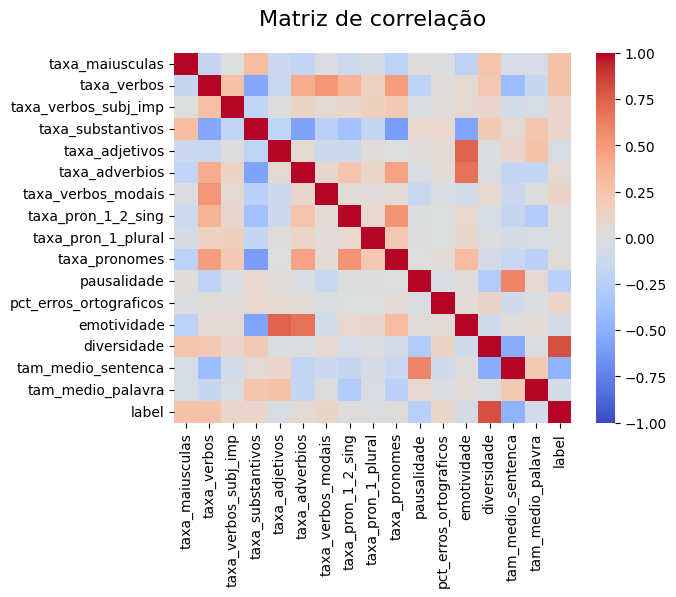

In [ ]:
sns.heatmap(matriz_correlacao, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Matriz de correlação", fontsize=16, pad=20)

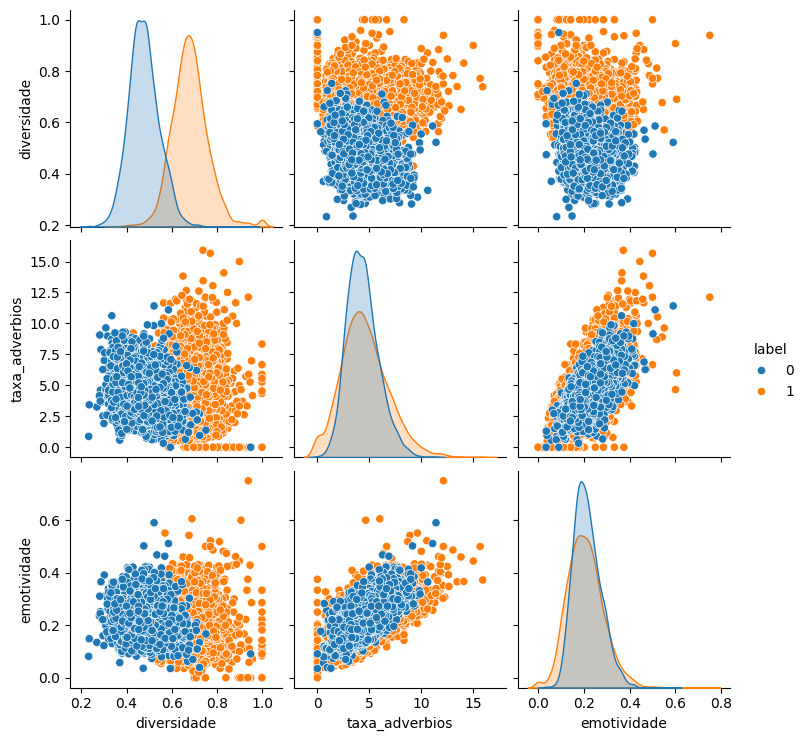

In [ ]:
sns.pairplot(df[[
    "taxa_maiusculas",
    "taxa_verbos",
    "taxa_verbos_subj_imp",
    "taxa_substantivos",
    "taxa_adjetivos",
    "taxa_adverbios",
    "taxa_verbos_modais",
    "taxa_pron_1_2_sing",
    "taxa_pron_1_plural",
    "taxa_pronomes",
    "pausalidade",
    "pct_erros_ortograficos",
    "emotividade",
    "diversidade",
    "tam_medio_sentenca",
    "tam_medio_palavra",
    "label"
]], hue="label", vars=["diversidade","taxa_adverbios","emotividade"])

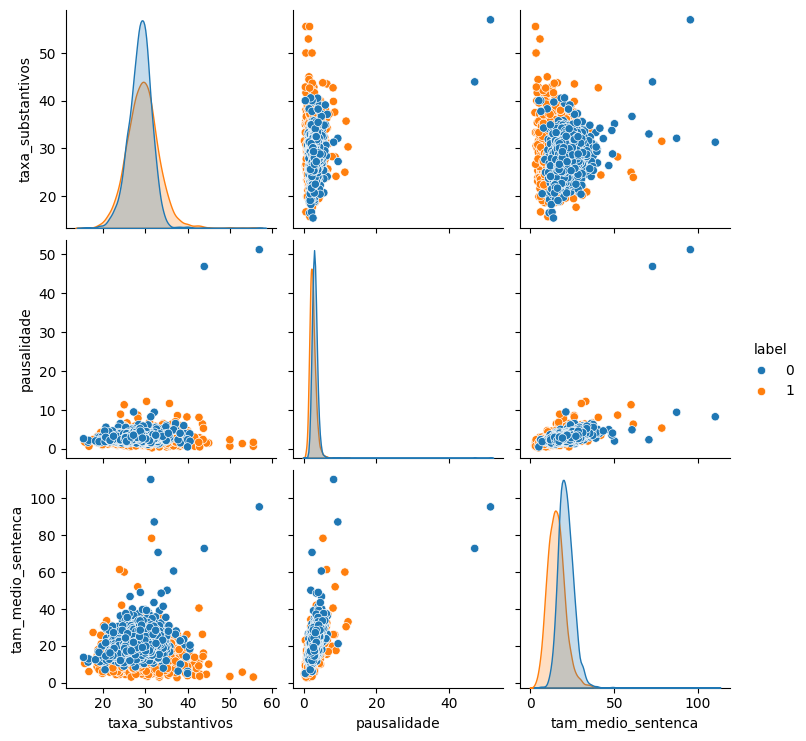

In [ ]:
sns.pairplot(df[[
    "taxa_maiusculas",
    "taxa_verbos",
    "taxa_verbos_subj_imp",
    "taxa_substantivos",
    "taxa_adjetivos",
    "taxa_adverbios",
    "taxa_verbos_modais",
    "taxa_pron_1_2_sing",
    "taxa_pron_1_plural",
    "taxa_pronomes",
    "pausalidade",
    "pct_erros_ortograficos",
    "emotividade",
    "diversidade",
    "tam_medio_sentenca",
    "tam_medio_palavra",
    "label"
]], hue="label", vars=["taxa_substantivos","pausalidade","tam_medio_sentenca"])

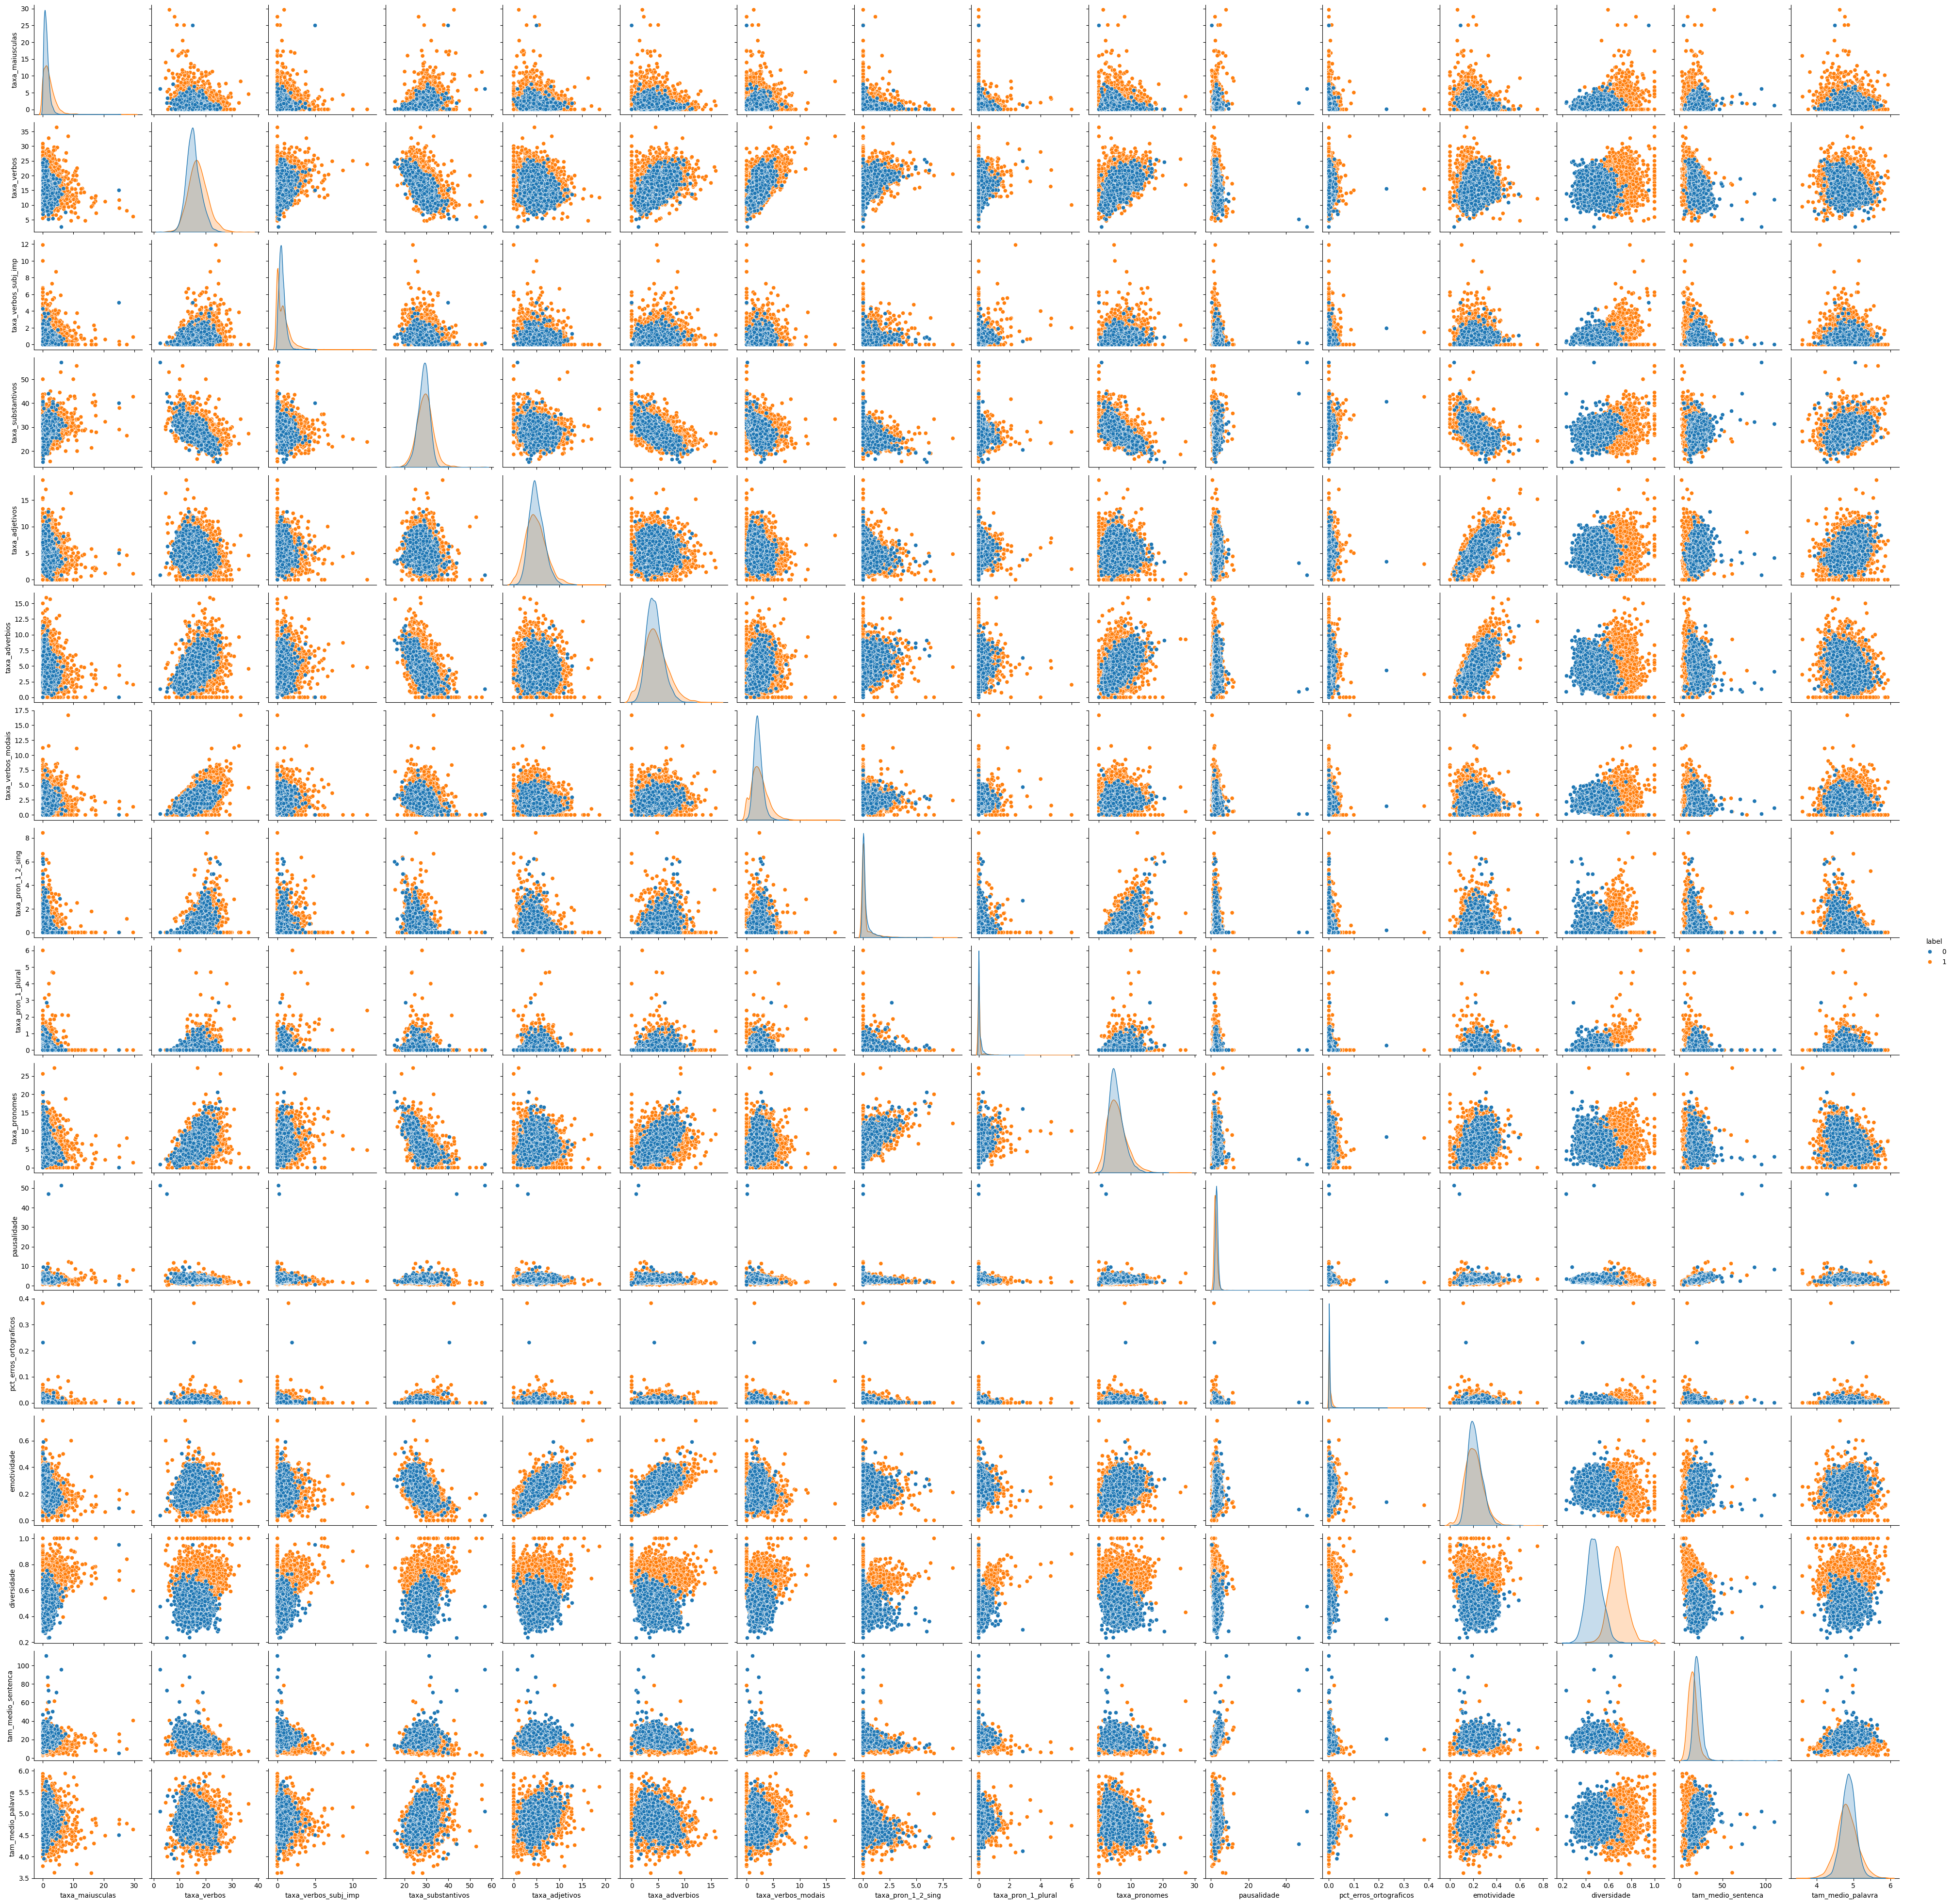

In [ ]:
sns.pairplot(df[[
    "taxa_maiusculas",
    "taxa_verbos",
    "taxa_verbos_subj_imp",
    "taxa_substantivos",
    "taxa_adjetivos",
    "taxa_adverbios",
    "taxa_verbos_modais",
    "taxa_pron_1_2_sing",
    "taxa_pron_1_plural",
    "taxa_pronomes",
    "pausalidade",
    "pct_erros_ortograficos",
    "emotividade",
    "diversidade",
    "tam_medio_sentenca",
    "tam_medio_palavra",
    "label"
]], hue="label")

In [ ]:
plt.figure(figsize=(8, 6))

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

#NOVO: Análise de multicolinearidade (VIF)

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [ ]:
colunas_features = [
    "taxa_maiusculas",
    "taxa_verbos",
    "taxa_verbos_subj_imp",
    "taxa_substantivos",
    "taxa_adjetivos",
    "taxa_adverbios",
    "taxa_verbos_modais",
    "taxa_pron_1_2_sing",
    "taxa_pron_1_plural",
    "taxa_pronomes",
    "pausalidade",
    "tam_medio_sentenca",
    "tam_medio_palavra",
    "pct_erros_ortograficos",
    "emotividade",
    "diversidade",
]

In [ ]:
corr_label = (
    matriz_correlacao["label"]
    .drop("label")
    .sort_values(key=lambda x: x.abs(), ascending=False)
)
print("--- Correlação com 'label' (ordenado por magnitude) ---")
print(corr_label)
print("\n")

X_vif = df_corr[colunas_features].dropna()

vif_data = pd.DataFrame()
vif_data["variavel"] = X_vif.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])
]
vif_data = vif_data.sort_values("VIF", ascending=False)

print("--- VIF por variável ---")
print(vif_data.to_string(index=False))
print("\n")

def remover_por_vif(X, limite=10):
    """Remove iterativamente a variável com maior VIF acima do limite."""
    X = X.copy()
    while True:
        vifs = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
        max_vif = max(vifs)
        if max_vif < limite:
            break
        idx_max = vifs.index(max_vif)
        col_removida = X.columns[idx_max]
        print(f"Removendo '{col_removida}' (VIF = {max_vif:.2f})")
        X = X.drop(columns=[col_removida])
    return X

X_reduzido = remover_por_vif(X_vif, limite=10)
print("--- Variáveis finais após remoção por VIF ---")
print(list(X_reduzido.columns))

--- Correlação com 'label' (ordenado por magnitude) ---
diversidade               0.809538
tam_medio_sentenca       -0.479810
taxa_maiusculas           0.259801
taxa_verbos               0.258709
pausalidade              -0.248866
taxa_verbos_modais        0.112935
pct_erros_ortograficos    0.102139
taxa_verbos_subj_imp      0.096085
taxa_substantivos         0.094346
tam_medio_palavra        -0.082807
emotividade              -0.057669
taxa_adverbios            0.054314
taxa_adjetivos           -0.039474
taxa_pronomes             0.022083
taxa_pron_1_2_sing        0.011843
taxa_pron_1_plural       -0.009397
Name: label, dtype: float64


--- VIF por variável ---
              variavel        VIF
           emotividade 105.499699
        taxa_adjetivos  44.878975
        taxa_adverbios  41.371115
           taxa_verbos   7.326168
     taxa_substantivos   7.118710
    tam_medio_sentenca   2.498507
         taxa_pronomes   2.215188
           diversidade   1.727123
           pausalidade 

### FIM DO TRATAMENTO

Split de treino e teste

In [ ]:
colunas_uteis = [
    "taxa_maiusculas",
    "taxa_verbos",
    "taxa_verbos_subj_imp",
    "taxa_substantivos",
    "taxa_adjetivos",
    "taxa_adverbios",
    "taxa_verbos_modais",
    "taxa_pron_1_2_sing",
    "taxa_pron_1_plural",
    "taxa_pronomes",
    "pausalidade",
    "pct_erros_ortograficos",
    "tam_medio_sentenca",
    "tam_medio_palavra",
    "emotividade",
    "diversidade",
]

In [ ]:
from sklearn.model_selection import train_test_split

X = df[["texto_trunc"] + colunas_uteis]
y = df["label"]

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

IMPLEMENTANDO TF-IDF

In [ ]:
pipe_base = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True, stop_words=None,
        ngram_range=(1, 2), min_df=2, sublinear_tf=True
    )),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

scores = cross_val_score(
    pipe_base, X_tr["texto_trunc"], y_tr, cv=5, scoring="f1_macro"
)
print(scores.mean(), scores.std())

0.9268852111611234 0.0032791041976040895


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

prep = ColumnTransformer([
    ("txt_word", TfidfVectorizer(ngram_range=(1,2), min_df=2,
                                 sublinear_tf=True, stop_words=None), "texto_trunc"),
    ("txt_char", TfidfVectorizer(analyzer="char_wb", ngram_range=(3,5),
                                 min_df=3, sublinear_tf=True), "texto_trunc"),
    ("meta", Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("sc", StandardScaler())
    ]), colunas_uteis)
])

pipe_full = Pipeline([("prep", prep),
                      ("clf", LogisticRegression(max_iter=1000, class_weight="balanced"))])

In [ ]:
from sklearn.model_selection import cross_validate

scoring = ["accuracy", "f1_macro", "precision_macro", "recall_macro", "roc_auc"]

def avaliar_cv(pipe, X, y, nome):
    cv = cross_validate(pipe, X, y, cv=5, scoring=scoring, n_jobs=-1)
    return pd.Series(
        {m: cv[f"test_{m}"].mean() for m in scoring}
        | {f"{m}_std": cv[f"test_{m}"].std() for m in scoring},
        name=nome,
    )

tabela_cv = pd.DataFrame([
    avaliar_cv(pipe_base, X_tr["texto_trunc"], y_tr, "TF-IDF puro"),
    avaliar_cv(pipe_full, X_tr,               y_tr, "TF-IDF + metadados"),
])
print(tabela_cv.round(4))

                    accuracy  f1_macro  precision_macro  recall_macro  \
TF-IDF puro           0.9269    0.9269           0.9275        0.9269   
TF-IDF + metadados    0.9585    0.9585           0.9587        0.9585   

                    roc_auc  accuracy_std  f1_macro_std  precision_macro_std  \
TF-IDF puro          0.9780        0.0033        0.0033               0.0030   
TF-IDF + metadados   0.9909        0.0088        0.0088               0.0089   

                    recall_macro_std  roc_auc_std  
TF-IDF puro                   0.0033       0.0033  
TF-IDF + metadados            0.0088       0.0032  


VISUALIZAÇÕES SHAP VALUE

/tmp/ipykernel_4812/2860524865.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_4812/2860524865.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_4812/2860524865.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_4812/2860524865.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_4812/2860524865.py:18: FutureWarning: 

P

IndexError: index 9 is out of bounds for axis 0 with size 9

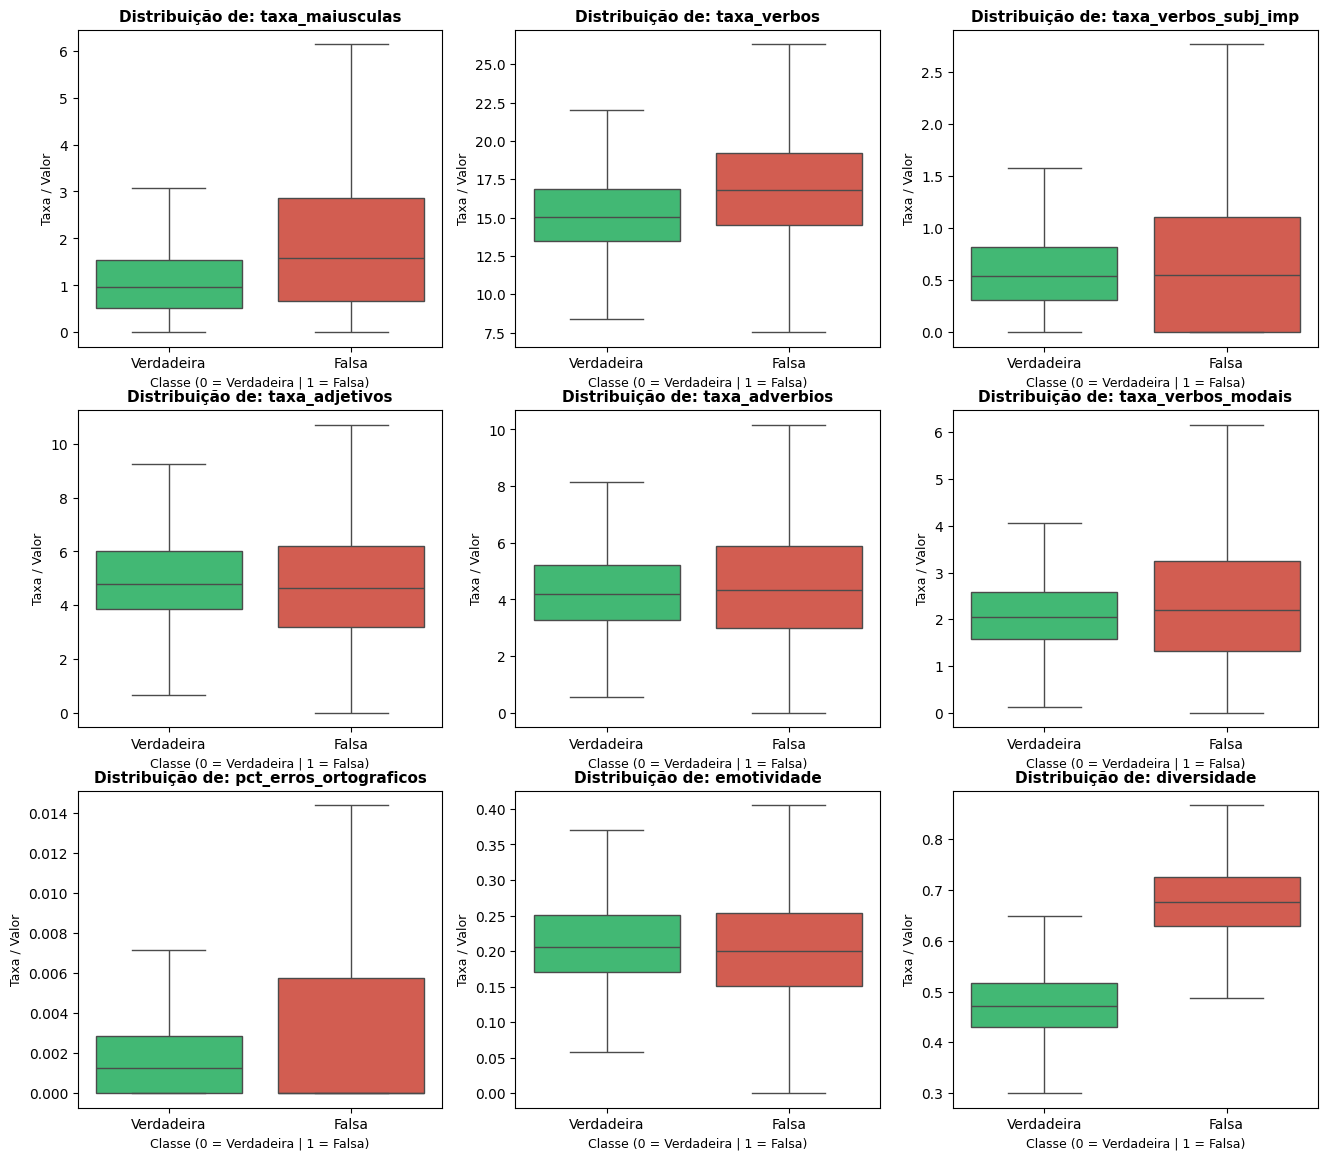

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

df_eda = df.copy()

# Lista com todas as features
colunas_analise = [
    'taxa_maiusculas', 'taxa_verbos', 'taxa_verbos_subj_imp',
    'taxa_adjetivos', 'taxa_adverbios', 'taxa_verbos_modais',
    'pct_erros_ortograficos', 'emotividade', 'diversidade', "tam_medio_sentenca"
]

# (grid 3x3)
fig, axes = plt.subplots(3, 3, figsize=(16, 14))
axes = axes.ravel()

for i, col in enumerate(colunas_analise):
    sns.boxplot(
        x="label",
        y=col,
        data=df_eda,
        ax=axes[i],
        palette=["#2ecc71", "#e74c3c"], # 0 = Verde (Verdadeira), 1 = Vermelho (Falsa)
        showfliers=False # Oculta outliers extremos para melhorar a visualização da distribuição central
    )
    axes[i].set_title(f'Distribuição de: {col}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Classe (0 = Verdadeira | 1 = Falsa)', fontsize=9)
    axes[i].set_ylabel('Taxa / Valor', fontsize=9)
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['Verdadeira', 'Falsa'])

plt.tight_layout()
plt.show()

In [ ]:
df.iloc[:,23]

In [ ]:
#!pip install shap xgboost

import shap
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Definição do conjunto de features (X) e da classe alvo (y)
features = [
    'taxa_maiusculas', 'taxa_verbos', 'taxa_verbos_subj_imp',
    'taxa_adjetivos', 'taxa_adverbios', 'taxa_verbos_modais',
    'pct_erros_ortograficos', 'emotividade','diversidade',
    'tam_medio_sentenca',#'num_tokens',
]

# Garantindo que o dataframe ativo contenha as colunas e tratando eventuais nulos
X = df[features].fillna(0)
y = df['label']

# Divisão da base em treino e teste (80% treino, 20% teste)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Treinamento do modelo baseado em árvore (Random Forest)
modelo = RandomForestClassifier(n_estimators=100, random_state=42)
modelo.fit(X_train, y_train)

# O TreeExplainer calcula rapidamente os Shapley Additive exPlanations
explainer = shap.TreeExplainer(modelo)
shap_values = explainer(X_test)

# calcular a acurácia do modelo
y_pred = modelo.predict(X_test)
acuracia = accuracy_score(y_test, y_pred)
print("Acurácia (%):", acuracia*100)

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.show()

In [ ]:
# Importância das features
importances = modelo.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
})

# Ordenar da mais importante para a menos importante
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

In [ ]:
df['taxa_maiusculas'].isna().sum()

In [ ]:
shap_values.feature_names = list(X_test.columns)
shap.plots.beeswarm(shap_values[:, :, 1])

In [ ]:
import numpy as np
import pandas as pd
import shap

# Calculando a matriz de interações globais para o modelo de árvores
interaction_values = explainer.shap_interaction_values(X_test)

# Tratando a dimensionalidade caso o modelo retorne listas por classe (ex: Random Forest binário)
if isinstance(interaction_values, list):
    inter_target = interaction_values[1] # Foco na classe de notícias falsas (1)
elif len(interaction_values.shape) == 4:
    inter_target = interaction_values[:, :, :, 1]
else:
    inter_target = interaction_values

# Calculando a média dos valores absolutos para ranquear as combinações mais fortes
mean_abs_interactions = np.mean(np.abs(inter_target), axis=0)

feature_names = list(X_test.columns)
n_features = len(feature_names)
pairs = []

# Varrendo a matriz para extrair os pares de variáveis e excluir a diagonal principal
for i in range(n_features):
    for j in range(i + 1, n_features):
        pairs.append({
            'feature_1': feature_names[i],
            'feature_2': feature_names[j],
            'forca_interacao': mean_abs_interactions[i, j]
        })

# Criando o ranking ordenado das combinações
df_interactions = pd.DataFrame(pairs).sort_values(by='forca_interacao', ascending=False)
print(df_interactions.head(10))

In [ ]:
# Selecionando automaticamente o par com maior força de interação do DataFrame gerado
top_f1 = df_interactions.iloc[0]['feature_1']
top_f2 = df_interactions.iloc[0]['feature_2']

# Plotando a interação bivariada
shap.plots.scatter(
    shap_values[:, top_f1, 1],
    color=shap_values[:, top_f2, 1]
)